# 00 — Kiểm tra môi trường và audit dataset

**Mục tiêu:** Ghi nhận môi trường, tải `tanganke/gtsrb`, audit chín split và tạo manifest train/validation cố định.

> Notebook này chỉ được người dùng chạy thủ công. Codex không được tự động thực thi notebook.

## 1. CẤU HÌNH

Các giá trị này là cấu hình duy nhất cần chỉnh trong notebook. Không dùng test hoặc corruption split để tạo validation.

In [1]:
from pathlib import Path

SEED = 42
DATASET_ID = "tanganke/gtsrb"
VALIDATION_SIZE = 0.15
EXPECTED_NUM_CLASSES = 43
EXPECTED_SPLITS = [
    "train", "test", "contrast", "gaussian_noise",
    "impulse_noise", "jpeg_compression", "motion_blur",
    "pixelate", "spatter",
]
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / "results"
CACHE_DIR = ROOT / "data" / "huggingface_cache"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Kiểm tra môi trường

Cell này chỉ đọc thông tin máy và package; không tải dataset và không huấn luyện model.

In [2]:
import importlib.metadata as metadata
import json
import platform
import sys

import psutil
import pandas as pd
import torch
import torchvision

package_names = ["torch", "torchvision", "datasets", "scikit-learn", "pandas", "matplotlib", "Pillow", "psutil", "onnx", "onnxruntime"]
package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = metadata.version(package_name)
    except metadata.PackageNotFoundError:
        package_versions[package_name] = None

gpu_available = torch.cuda.is_available()
gpu_info = []
if gpu_available:
    for device_index in range(torch.cuda.device_count()):
        properties = torch.cuda.get_device_properties(device_index)
        gpu_info.append({
            "name": properties.name,
            "total_memory_gb": round(properties.total_memory / (1024 ** 3), 2),
            "compute_capability": f"{properties.major}.{properties.minor}",
        })

environment = {
    "python_version": platform.python_version(),
    "python_executable": sys.executable,
    "platform": platform.platform(),
    "cpu_count": psutil.cpu_count(logical=True),
    "ram_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "cuda_available": gpu_available,
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
    "gpu": gpu_info,
    "packages": package_versions,
}
(RESULTS_DIR / "environment.json").write_text(json.dumps(environment, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(environment, indent=2, ensure_ascii=False))

{
  "python_version": "3.11.9",
  "python_executable": "d:\\DBM302m\\project\\robust-gtsrb-lite\\.venv\\Scripts\\python.exe",
  "platform": "Windows-10-10.0.22631-SP0",
  "cpu_count": 16,
  "ram_gb": 23.71,
  "torch_version": "2.11.0+cu128",
  "torchvision_version": "0.26.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "cudnn_version": 91900,
  "gpu": [
    {
      "name": "NVIDIA GeForce RTX 3050 Laptop GPU",
      "total_memory_gb": 4.0,
      "compute_capability": "8.6"
    }
  ],
  "packages": {
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "datasets": "4.8.4",
    "scikit-learn": "1.9.0",
    "pandas": "2.3.3",
    "matplotlib": "3.11.0",
    "Pillow": "12.2.0",
    "psutil": "7.2.2",
    "onnx": "1.22.0",
    "onnxruntime": "1.27.0"
  }
}


## 3. Tải và audit chín split

Nếu thiếu package, split, label hoặc ảnh không decode được thì dừng notebook và không tạo manifest.

In [3]:
from datasets import ClassLabel, load_dataset

dataset = load_dataset(DATASET_ID, cache_dir=str(CACHE_DIR))
actual_splits = list(dataset.keys())
missing_splits = [split_name for split_name in EXPECTED_SPLITS if split_name not in actual_splits]
if missing_splits:
    raise RuntimeError(f"Thiếu split bắt buộc: {missing_splits}; đã thấy: {actual_splits}")

def find_column(split):
    names = set(dataset[split].column_names)
    image_candidates = [name for name in ("image", "img") if name in names]
    label_candidates = [name for name in ("label", "labels", "class") if name in names]
    if len(image_candidates) != 1 or len(label_candidates) != 1:
        raise RuntimeError(f"Không xác định được cột ảnh/nhãn của split {split}: {dataset[split].column_names}")
    return image_candidates[0], label_candidates[0]

audit = {"dataset_id": DATASET_ID, "splits": {}, "expected_splits": EXPECTED_SPLITS}
label_column = None
image_column = None
for split_name in EXPECTED_SPLITS:
    split = dataset[split_name]
    current_image_column, current_label_column = find_column(split_name)
    image_column = image_column or current_image_column
    label_column = label_column or current_label_column
    labels = split[current_label_column]
    label_feature = split.features[current_label_column]
    label_names = list(label_feature.names) if isinstance(label_feature, ClassLabel) else None
    invalid_labels = sum(label < 0 or label >= EXPECTED_NUM_CLASSES for label in labels)
    first_image = split[0][current_image_column].convert("RGB")
    audit["splits"][split_name] = {
        "num_rows": len(split),
        "columns": split.column_names,
        "features": {name: str(feature) for name, feature in split.features.items()},
        "label_column": current_label_column,
        "image_column": current_image_column,
        "num_classes": len(label_names) if label_names is not None else len(set(labels)),
        "label_names": label_names,
        "invalid_label_count": invalid_labels,
        "first_image_mode_after_rgb": first_image.mode,
        "first_image_size": list(first_image.size),
    }

test_labels = dataset["test"][label_column]
for split_name in EXPECTED_SPLITS[2:]:
    corruption_labels = dataset[split_name][label_column]
    audit["splits"][split_name]["label_histogram_matches_test"] = sorted(corruption_labels) == sorted(test_labels)
    if len(corruption_labels) != len(test_labels) or not audit["splits"][split_name]["label_histogram_matches_test"]:
        raise RuntimeError(f"Label corruption split không khớp test: {split_name}")

for split_name, split_info in audit["splits"].items():
    if split_info["num_classes"] != EXPECTED_NUM_CLASSES or split_info["invalid_label_count"]:
        raise RuntimeError(f"Split {split_name} không đạt kiểm tra 43 lớp hoặc có label lỗi")
audit["image_column"] = image_column
audit["label_column"] = label_column
(RESULTS_DIR / "dataset_audit.json").write_text(json.dumps(audit, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(audit, indent=2, ensure_ascii=False))

d:\DBM302m\project\robust-gtsrb-lite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating spatter split: 100%|██████████| 12630/12630 [00:00<00:00, 70131.34 examples/s]


{
  "dataset_id": "tanganke/gtsrb",
  "splits": {
    "train": {
      "num_rows": 26640,
      "columns": [
        "image",
        "label"
      ],
      "features": {
        "image": "Image(mode=None, decode=True)",
        "label": "ClassLabel(names=['red and white circle 20 kph speed limit', 'red and white circle 30 kph speed limit', 'red and white circle 50 kph speed limit', 'red and white circle 60 kph speed limit', 'red and white circle 70 kph speed limit', 'red and white circle 80 kph speed limit', 'end / de-restriction of 80 kph speed limit', 'red and white circle 100 kph speed limit', 'red and white circle 120 kph speed limit', 'red and white circle red car and black car no passing', 'red and white circle red truck and black car no passing', 'red and white triangle road intersection warning', 'white and yellow diamond priority road', 'red and white upside down triangle yield right-of-way', 'stop', 'empty red and white circle', 'red and white circle no truck entry', 'red ci

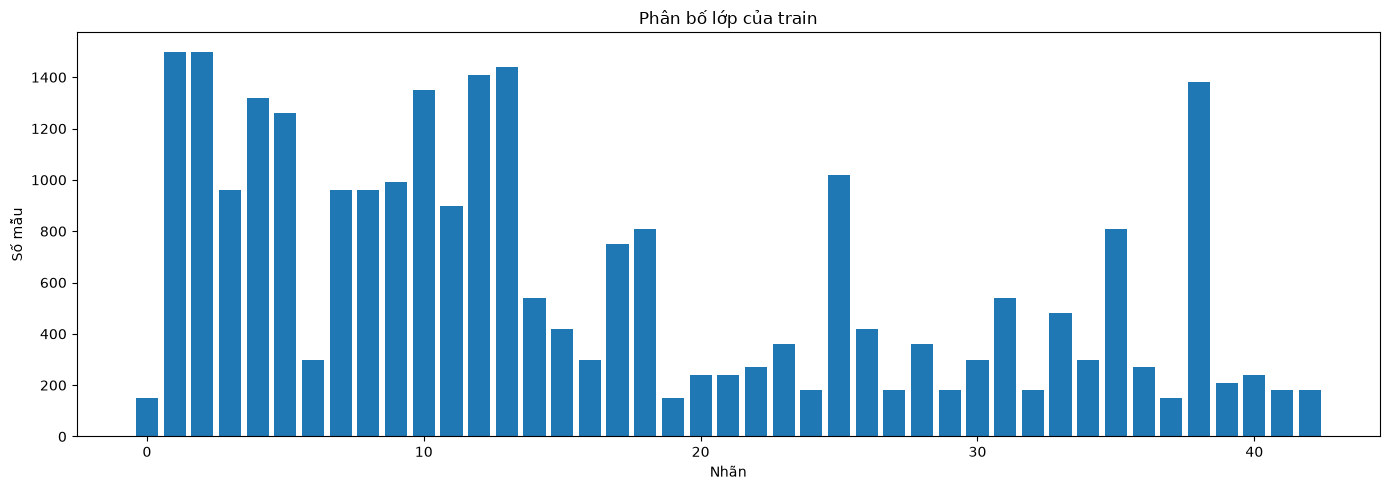

In [4]:
from collections import Counter
import random
import numpy as np
from sklearn.model_selection import train_test_split

random.seed(SEED)
np.random.seed(SEED)
train_labels = np.asarray(dataset["train"][label_column])
train_indices = np.arange(len(train_labels))
train_part, validation_part = train_test_split(
    train_indices, test_size=VALIDATION_SIZE, random_state=SEED, stratify=train_labels
)
manifest = pd.DataFrame({
    "source_split": "train",
    "source_index": np.concatenate([train_part, validation_part]),
    "partition": ["train"] * len(train_part) + ["validation"] * len(validation_part),
    "label": train_labels[np.concatenate([train_part, validation_part])],
})
manifest = manifest.sort_values("source_index").reset_index(drop=True)
manifest.to_csv(RESULTS_DIR / "split_manifest.csv", index=False, encoding="utf-8")

import matplotlib.pyplot as plt
class_counts = Counter(train_labels.tolist())
plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Nhãn")
plt.ylabel("Số mẫu")
plt.title("Phân bố lớp của train")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "train_class_distribution.png", dpi=150)
plt.show()

## 4. TÓM TẮT TRẠNG THÁI

Cell cuối chỉ báo trạng thái từ artifact đã ghi; không điền số liệu trước khi chạy.

In [5]:
required_artifacts = [
    RESULTS_DIR / "environment.json",
    RESULTS_DIR / "dataset_audit.json",
    RESULTS_DIR / "split_manifest.csv",
    RESULTS_DIR / "train_class_distribution.png",
]
missing_artifacts = [str(path) for path in required_artifacts if not path.exists()]
if missing_artifacts:
    raise RuntimeError(f"Thiếu artifact: {missing_artifacts}")
print("STATUS: PASS")
print("Artifacts:")
for path in required_artifacts:
    print(f"- {path.relative_to(ROOT)}")
print(f"Train: {len(train_part)} mẫu; validation: {len(validation_part)} mẫu")
print("Chưa thực hiện huấn luyện model.")

STATUS: PASS
Artifacts:
- results\environment.json
- results\dataset_audit.json
- results\split_manifest.csv
- results\train_class_distribution.png
Train: 22644 mẫu; validation: 3996 mẫu
Chưa thực hiện huấn luyện model.
